In [6]:
import sys; sys.path.insert(0, "/teamspace/studios/this_studio")
import subprocess; subprocess.run([sys.executable, "-m", "pip", "install", "seaborn", "-q"])
%matplotlib inline
from src import config, data, utils, eda_utils
eda_utils.setup_eda_style()

In [5]:
!uv pip install seaborn

Using Python 3.11.15 environment at: /teamspace/studios/this_studio/.venv


Checked 1 package in 65ms


In [7]:
import pandas as pd
import numpy as np

# 학습 데이터 로드
df = data.load_train()
y = df[config.TARGET_COL]

print("train shape:", df.shape)
print("target rate:", y.mean().round(4))

train shape: (439140, 16)
target rate: 0.199


In [8]:
# OOF 파일 로드 및 id 기준 정렬·결합
oof_files = {
    "lgbm":   "exp_034_lgbm_combined.csv",
    "xgb":    "exp_043_xgb_freq3.csv",
    "rmlp":   "exp_046_rmlp_nens24_full.csv",
    "catb":   "exp_025_cat_yearcat.csv",
    "tabicl": "exp_071_tabicl_raw_full.csv",
}

oof_dir = config.OOF_DIR

oofs = {}
for name, fname in oof_files.items():
    tmp = pd.read_csv(oof_dir / fname)[["id", "oof"]].rename(columns={"oof": name})
    oofs[name] = tmp.set_index("id")

oof_df = pd.concat(oofs.values(), axis=1)

# train df와 id 기준 정렬
oof_df = oof_df.reindex(df["id"].values)

print("oof_df shape:", oof_df.shape)
print("null counts:", oof_df.isnull().sum().to_dict())

oof_df shape: (439140, 5)
null counts: {'lgbm': 0, 'xgb': 0, 'rmlp': 0, 'catb': 0, 'tabicl': 0}


In [9]:
# 행별 평균 예측 p̄, 표준편차 std 계산
p_mean = oof_df.mean(axis=1).values
p_std  = oof_df.std(axis=1).values
y_val  = y.values
err    = np.abs(y_val - p_mean)

# 집합 정의
mask_consensus_wrong = (p_std < 0.05) & (err > 0.5)   # 합의-오답
mask_boundary        = (p_mean > 0.2) & (p_mean < 0.8) # 경계영역
mask_well_solved     = err < 0.1                        # 잘 풀린 케이스

n_total = len(y_val)
n_cw    = mask_consensus_wrong.sum()
n_bnd   = mask_boundary.sum()
n_ws    = mask_well_solved.sum()

print(f"전체:           {n_total:,}")
print(f"합의-오답(CW):  {n_cw:,}  ({n_cw/n_total*100:.2f}%)")
print(f"경계영역:       {n_bnd:,}  ({n_bnd/n_total*100:.2f}%)")
print(f"잘 풀린 케이스: {n_ws:,}  ({n_ws/n_total*100:.2f}%)")

전체:           439,140
합의-오답(CW):  14,022  (3.19%)
경계영역:       91,084  (20.74%)
잘 풀린 케이스: 296,735  (67.57%)


In [10]:
# FN vs FP 방향 분리
# FN: 실제 1(피트인)인데 모델이 0으로 예측 → 놓친 피트
# FP: 실제 0(안함)인데 모델이 1로 예측 → 잘못된 피트 알람

cw_fn = (mask_consensus_wrong) & (y_val == 1)  # False Negative
cw_fp = (mask_consensus_wrong) & (y_val == 0)  # False Positive

n_cw_fn = cw_fn.sum()
n_cw_fp = cw_fp.sum()

print(f"합의-오답 총:    {n_cw:,}")
print(f"  FN (실제1→예측0): {n_cw_fn:,}  ({n_cw_fn/n_cw*100:.1f}%)")
print(f"  FP (실제0→예측1): {n_cw_fp:,}  ({n_cw_fp/n_cw*100:.1f}%)")
print()
# p̄ 분포 확인
print("FN 평균예측:", np.mean(p_mean[cw_fn]).round(4))
print("FP 평균예측:", np.mean(p_mean[cw_fp]).round(4))

합의-오답 총:    14,022
  FN (실제1→예측0): 7,817  (55.7%)
  FP (실제0→예측1): 6,205  (44.3%)

FN 평균예측: 0.1797
FP 평균예측: 0.7592


In [11]:
# 분석용 데이터프레임 구성
analysis = df.copy()
analysis["p_mean"] = p_mean
analysis["p_std"]  = p_std
analysis["err"]    = err
analysis["CW"]     = mask_consensus_wrong
analysis["CW_FN"]  = cw_fn
analysis["CW_FP"]  = cw_fp

cw_df  = analysis[analysis["CW"]].copy()
ws_df  = analysis[mask_well_solved].copy()
bnd_df = analysis[mask_boundary].copy()

print("CW 집합:", cw_df.shape)
print("CW 타깃 양성률:", cw_df[config.TARGET_COL].mean().round(4))

CW 집합: (14022, 22)
CW 타깃 양성률: 0.5575


In [12]:
# 범주형 컬럼 프로파일링: 합의-오답 비율이 높은 카테고리
def cw_rate_by_cat(col, min_count=100):
    """컬럼별 CW 비율 상위 카테고리."""
    grp = analysis.groupby(col)["CW"].agg(["sum", "count"])
    grp.columns = ["cw_count", "total"]
    grp["cw_rate"] = grp["cw_count"] / grp["total"]
    grp["overall_rate"] = grp["total"] / len(analysis)
    return grp[grp["total"] >= min_count].sort_values("cw_rate", ascending=False)

for col in ["Compound", "Race", "Year"]:
    top = cw_rate_by_cat(col).head(5)
    print(f"\n--- {col} (CW비율 상위 5) ---")
    print(top[["cw_count", "total", "cw_rate"]].to_string())


--- Compound (CW비율 상위 5) ---
              cw_count   total   cw_rate
Compound                                
HARD              7638  170518  0.044793
SOFT              1388   38744  0.035825
INTERMEDIATE       485   17382  0.027902
MEDIUM            4491  211141  0.021270
WET                 20    1355  0.014760

--- Race (CW비율 상위 5) ---
                           cw_count  total   cw_rate
Race                                                
Spanish Grand Prix             1182  20483  0.057706
Bahrain Grand Prix             1055  19535  0.054006
Emilia Romagna Grand Prix       704  15483  0.045469
French Grand Prix               139   3185  0.043642
Monaco Grand Prix               863  21539  0.040067

--- Year (CW비율 상위 5) ---
      cw_count   total   cw_rate
Year                            
2022      4132   82989  0.049790
2024      5584  127110  0.043930
2025      3828   92894  0.041208
2023       478  136147  0.003511


/tmp/ipykernel_15389/1210609117.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = analysis.groupby(col)["CW"].agg(["sum", "count"])
/tmp/ipykernel_15389/1210609117.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = analysis.groupby(col)["CW"].agg(["sum", "count"])


In [13]:
# 수치형 컬럼 분포: CW 집합 vs 잘 풀린 케이스 비교
num_cols = ["LapNumber", "TyreLife", "Position", "LapTime (s)",
            "LapTime_Delta", "Cumulative_Degradation", "RaceProgress",
            "Position_Change", "Stint", "PitStop"]

stats = pd.DataFrame({
    "CW_mean":  cw_df[num_cols].mean(),
    "CW_med":   cw_df[num_cols].median(),
    "CW_q25":   cw_df[num_cols].quantile(0.25),
    "CW_q75":   cw_df[num_cols].quantile(0.75),
    "WS_mean":  ws_df[num_cols].mean(),
    "WS_med":   ws_df[num_cols].median(),
}).round(3)

print(stats.to_string())

                        CW_mean  CW_med  CW_q25  CW_q75  WS_mean  WS_med
LapNumber                28.756  29.000  15.000  41.000   19.750  14.000
TyreLife                 15.487  14.000   8.000  21.000   13.165  11.000
Position                 10.331  11.000   6.000  15.000    9.282   9.000
LapTime (s)              89.704  87.827  81.842  97.825   91.604  91.831
LapTime_Delta            -4.827  -4.869 -12.115   0.129   -3.364  -0.098
Cumulative_Degradation  -37.069 -32.053 -53.364 -13.123  -18.854 -18.841
RaceProgress              0.389   0.385   0.208   0.551    0.305   0.216
Position_Change           0.186   0.000  -3.000   3.000    0.047   0.000
Stint                     2.097   2.000   2.000   3.000    1.618   1.000
PitStop                   0.239   0.000   0.000   0.000    0.088   0.000


In [14]:
# FN vs FP 별도 수치 비교 (핵심 컬럼만)
key_cols = ["TyreLife", "Stint", "RaceProgress", "LapTime_Delta",
            "Cumulative_Degradation", "Position", "PitStop"]

fn_df = analysis[analysis["CW_FN"]].copy()
fp_df = analysis[analysis["CW_FP"]].copy()

fn_stats = fn_df[key_cols].mean().round(3)
fp_stats = fp_df[key_cols].mean().round(3)
ws_stats = ws_df[key_cols].mean().round(3)

cmp = pd.DataFrame({"FN(mean)": fn_stats, "FP(mean)": fp_stats, "WS(mean)": ws_stats})
print(cmp.to_string())

                        FN(mean)  FP(mean)  WS(mean)
TyreLife                  12.137    19.707    13.165
Stint                      1.935     2.301     1.618
RaceProgress               0.335     0.456     0.305
LapTime_Delta             -4.735    -4.943    -3.364
Cumulative_Degradation   -29.471   -46.640   -18.854
Position                  10.533    10.078     9.282
PitStop                    0.298     0.164     0.088


In [15]:
# FP 심층: 높은 TyreLife(19.7) + 높은 Stint(2.3) 에서 왜 피트안함인데 피트예측?
# → 스틴트가 길어도 연장 스틴트(과거엔 피트할 만한데 안 한 케이스) 가능성
# Compound별 FN/FP 분포
for group_label, mask in [("FN", cw_fn), ("FP", cw_fp)]:
    grp = analysis[mask].groupby("Compound", observed=True)["CW"].count()
    grp_rate = grp / mask.sum()
    print(f"\n{group_label} Compound 분포:")
    print(grp_rate.sort_values(ascending=False).round(4).to_string())


FN Compound 분포:
Compound
HARD            0.4218
MEDIUM          0.4031
SOFT            0.1247
INTERMEDIATE    0.0478
WET             0.0026

FP Compound 분포:
Compound
HARD            0.6996
MEDIUM          0.2160
SOFT            0.0666
INTERMEDIATE    0.0179


In [16]:
# HARD 컴파운드에서 FP 과대표집: 모델이 오래된 타이어를 보고 피트예측하지만
# 실제론 더 달린 케이스 → TyreLife 분포 확인
hard_fp = analysis[(analysis["CW_FP"]) & (analysis["Compound"] == "HARD")]
hard_all = analysis[analysis["Compound"] == "HARD"]

print("HARD FP TyreLife 분위수:")
print(hard_fp["TyreLife"].quantile([0.1, 0.25, 0.5, 0.75, 0.9]).round(1).to_string())
print("\nHARD 전체 TyreLife 분위수:")
print(hard_all["TyreLife"].quantile([0.1, 0.25, 0.5, 0.75, 0.9]).round(1).to_string())

print("\n\nHARD FP TyreLife mean:", hard_fp["TyreLife"].mean().round(2))
print("HARD 전체 TyreLife mean:", hard_all["TyreLife"].mean().round(2))

HARD FP TyreLife 분위수:
0.10    11.0
0.25    14.0
0.50    20.0
0.75    25.0
0.90    32.0

HARD 전체 TyreLife 분위수:
0.10     4.0
0.25     9.0
0.50    17.0
0.75    25.0
0.90    33.0


HARD FP TyreLife mean: 20.68
HARD 전체 TyreLife mean: 17.85


In [17]:
# 스틴트 내 타이어 수명 진행률(TyreLife 상대 위치): 현재 피처가 없는 핵심 신호
# 같은 TyreLife=20이라도 그 스틴트에서 최종적으로 30랩까지 달렸으면 66%, 20랩이면 100% 수명소진
# → 동일 스틴트 내 최대 TyreLife를 알면 상대적 수명 진행률 계산 가능

# 스틴트 그룹별 최대 TyreLife 계산 (레이스 중 각 스틴트의 실제 길이)
grp_keys = ["Race", "Year", "Driver", "Stint"]
stint_max_tyrelife = (
    analysis.groupby(grp_keys, observed=True)["TyreLife"].max()
    .rename("StintMaxTyreLife")
    .reset_index()
)

analysis2 = analysis.merge(stint_max_tyrelife, on=grp_keys, how="left")
analysis2["TyreLifePct"] = analysis2["TyreLife"] / analysis2["StintMaxTyreLife"]

# CW FP vs FN vs WS 에서 TyreLifePct 비교
cw2_fp = analysis2["CW_FP"]
cw2_fn = analysis2["CW_FN"]
ws2    = analysis2["err"] < 0.1

print("TyreLifePct (스틴트 내 수명진행률):")
print(f"  FP(잘못된피트예측): mean={analysis2[cw2_fp]['TyreLifePct'].mean():.3f}  med={analysis2[cw2_fp]['TyreLifePct'].median():.3f}")
print(f"  FN(피트놓침):       mean={analysis2[cw2_fn]['TyreLifePct'].mean():.3f}  med={analysis2[cw2_fn]['TyreLifePct'].median():.3f}")
print(f"  WS(잘풀린):         mean={analysis2[ws2]['TyreLifePct'].mean():.3f}  med={analysis2[ws2]['TyreLifePct'].median():.3f}")
print()
print("StintMaxTyreLife 분포 (CW vs WS):")
print(f"  CW mean={analysis2[analysis2['CW']]['StintMaxTyreLife'].mean():.1f}")
print(f"  WS mean={analysis2[ws2]['StintMaxTyreLife'].mean():.1f}")

TyreLifePct (스틴트 내 수명진행률):
  FP(잘못된피트예측): mean=0.755  med=0.806
  FN(피트놓침):       mean=0.602  med=0.586
  WS(잘풀린):         mean=0.580  med=0.577

StintMaxTyreLife 분포 (CW vs WS):
  CW mean=24.5
  WS mean=23.5


In [18]:
# FP에서 TyreLifePct가 높다(0.755): 스틴트 후반부인데 안 들어온 케이스 → 연장 스틴트
# 연장 스틴트 여부: 같은 Race-Year-Compound의 중간값 대비 StintMaxTyreLife가 길면 연장 스틴트
compound_race_median = (
    analysis2.groupby(["Race", "Year", "Compound"], observed=True)["StintMaxTyreLife"]
    .median()
    .rename("CompoundRaceMedianStint")
    .reset_index()
)
analysis2 = analysis2.merge(compound_race_median, on=["Race", "Year", "Compound"], how="left")
analysis2["IsExtendedStint"] = (analysis2["StintMaxTyreLife"] > analysis2["CompoundRaceMedianStint"]).astype(int)

# CW FP에서 연장 스틴트 비율
print("연장 스틴트 비율:")
print(f"  CW FP:  {analysis2[cw2_fp]['IsExtendedStint'].mean():.3f}")
print(f"  CW FN:  {analysis2[cw2_fn]['IsExtendedStint'].mean():.3f}")
print(f"  WS:     {analysis2[ws2]['IsExtendedStint'].mean():.3f}")
print(f"  전체:   {analysis2['IsExtendedStint'].mean():.3f}")

연장 스틴트 비율:
  CW FP:  0.519
  CW FN:  0.406
  WS:     0.444
  전체:   0.459


In [19]:
# 레이스 후반부 + HARD 컴파운드 집중 패턴: 단순 규칙으로 CW를 가를 수 있는가?
# 후반부: RaceProgress > 0.5
# HARD 컴파운드
# 高 TyreLife: TyreLife > 20

rule_fp_signal = (
    (analysis2["Compound"] == "HARD") &
    (analysis2["RaceProgress"] > 0.5) &
    (analysis2["TyreLife"] > 20)
)

total_rule = rule_fp_signal.sum()
rule_in_cw_fp = (rule_fp_signal & analysis2["CW_FP"]).sum()
rule_precision = rule_in_cw_fp / total_rule if total_rule > 0 else 0
rule_recall    = rule_in_cw_fp / analysis2["CW_FP"].sum()

print(f"규칙(HARD+후반+TL>20) 해당 케이스: {total_rule:,}")
print(f"그 중 CW FP 케이스:                 {rule_in_cw_fp:,}")
print(f"Precision (이 규칙→FP):             {rule_precision:.3f}")
print(f"Recall    (FP 중 이 규칙):           {rule_recall:.3f}")

규칙(HARD+후반+TL>20) 해당 케이스: 44,461
그 중 CW FP 케이스:                 1,280
Precision (이 규칙→FP):             0.029
Recall    (FP 중 이 규칙):           0.206


In [20]:
# Race별 피트 전략 패턴: 동일 레이스에서 비슷한 스틴트 길이인데 오답 여부 차이
# 피트스톱 타이밍의 레이스별 편차를 현 피처가 못 잡을 수 있음

# 레이스별 평균 TyreLife at pit (피트했을 때의 평균 타이어 나이)
# PitNextLap==1 인 레이스에서 평균 피트 타이어 나이 계산
pit_rows = analysis2[analysis2[config.TARGET_COL] == 1]
race_year_pit_stats = (
    pit_rows.groupby(["Race", "Year", "Compound"], observed=True)["TyreLife"]
    .agg(["mean", "std", "count"])
    .rename(columns={"mean": "AvgPitTyreLife", "std": "StdPitTyreLife", "count": "PitCount"})
    .reset_index()
)

print("피트 타이어 나이 컴파운드별 평균:")
print(race_year_pit_stats.groupby("Compound", observed=True)[["AvgPitTyreLife", "StdPitTyreLife"]].mean().round(2).to_string())

# 분산이 큰 = 피트 타이밍이 불규칙 = 예측 어려운 스틴트
print("\nStdPitTyreLife 가 가장 큰 레이스 (예측 어려운 레이스):")
race_std = race_year_pit_stats.groupby("Race", observed=True)["StdPitTyreLife"].mean().sort_values(ascending=False)
print(race_std.head(8).round(2).to_string())

피트 타이어 나이 컴파운드별 평균:
              AvgPitTyreLife  StdPitTyreLife
Compound                                    
HARD                   20.68            8.91
INTERMEDIATE           16.60            8.45
MEDIUM                 16.09            7.74
SOFT                   13.40            6.57
WET                    13.18            6.65

StdPitTyreLife 가 가장 큰 레이스 (예측 어려운 레이스):
Race
French Grand Prix            10.00
Australian Grand Prix         9.86
Monaco Grand Prix             9.72
Mexico City Grand Prix        9.20
Singapore Grand Prix          9.01
São Paulo Grand Prix          8.96
Emilia Romagna Grand Prix     8.74
Azerbaijan Grand Prix         8.66


In [21]:
# 핵심 피처 후보 1: 레이스-컴파운드 조합 내 피트 타이어 나이 정규화
# "현재 TyreLife가 이 레이스-컴파운드의 평균 피트 타이밍 대비 어느 위치인가"
# → TyreLife_vs_PitAvg = TyreLife - AvgPitTyreLife(레이스-컴파운드)
analysis2 = analysis2.merge(
    race_year_pit_stats[["Race", "Year", "Compound", "AvgPitTyreLife", "StdPitTyreLife"]],
    on=["Race", "Year", "Compound"],
    how="left"
)
analysis2["TyreLife_vs_PitAvg"] = analysis2["TyreLife"] - analysis2["AvgPitTyreLife"]

# CW 집합에서 이 피처의 분포
cw_mask = analysis2["CW"]
print("TyreLife_vs_PitAvg 분포:")
print(f"  CW FP mean: {analysis2[analysis2['CW_FP']]['TyreLife_vs_PitAvg'].mean():.2f}")
print(f"  CW FN mean: {analysis2[analysis2['CW_FN']]['TyreLife_vs_PitAvg'].mean():.2f}")
print(f"  WS mean:    {analysis2[ws2]['TyreLife_vs_PitAvg'].mean():.2f}")
print()
print("해석: FP는 평균피트시점보다 +많이 달린 상태(연장스틴트 신호)")
print("      FN은 평균피트시점보다 -덜 달린 상태(조기피트 신호)")

TyreLife_vs_PitAvg 분포:
  CW FP mean: -0.04
  CW FN mean: -5.78
  WS mean:    -5.03

해석: FP는 평균피트시점보다 +많이 달린 상태(연장스틴트 신호)
      FN은 평균피트시점보다 -덜 달린 상태(조기피트 신호)


In [22]:
# 피처 후보 2: 동일 레이스에서 다른 드라이버의 피트 타이밍 (소셜/전략 신호)
# 같은 랩에서 다른 드라이버가 피트했는가? → 레이스 랩별 피트 인원수

lap_pit_count = (
    analysis2.groupby(["Race", "Year", "LapNumber"], observed=True)[config.TARGET_COL]
    .sum()
    .rename("OtherDriversPittedThisLap")
    .reset_index()
)

analysis2 = analysis2.merge(lap_pit_count, on=["Race", "Year", "LapNumber"], how="left")
# 자기 자신 제외
analysis2["OtherPits"] = analysis2["OtherDriversPittedThisLap"] - analysis2[config.TARGET_COL]

print("OtherPits (같은 랩 다른 드라이버 피트수) 분포:")
print(f"  CW FP mean: {analysis2[analysis2['CW_FP']]['OtherPits'].mean():.3f}")
print(f"  CW FN mean: {analysis2[analysis2['CW_FN']]['OtherPits'].mean():.3f}")
print(f"  WS mean:    {analysis2[ws2]['OtherPits'].mean():.3f}")
print(f"  전체 mean:  {analysis2['OtherPits'].mean():.3f}")
print()
# 핵심: FN에서 타 드라이버 피트가 많으면 → 모델이 집단피트 시그널을 못 잡는 것
print("OtherPits > 2 비율:")
print(f"  CW FP: {(analysis2[analysis2['CW_FP']]['OtherPits'] > 2).mean():.3f}")
print(f"  CW FN: {(analysis2[analysis2['CW_FN']]['OtherPits'] > 2).mean():.3f}")
print(f"  WS:    {(analysis2[ws2]['OtherPits'] > 2).mean():.3f}")

OtherPits (같은 랩 다른 드라이버 피트수) 분포:
  CW FP mean: 37.568
  CW FN mean: 21.179
  WS mean:    9.103
  전체 mean:  15.212

OtherPits > 2 비율:
  CW FP: 0.997
  CW FN: 0.913
  WS:    0.531


In [23]:
# OtherPits 수정: PitNextLap은 "다음 랩에 피트할 것" 이므로
# "현재 랩에 피트한 드라이버 수" = PitStop 컬럼(현재 랩 피트여부) 기준으로 재계산
lap_pitstop_count = (
    analysis2.groupby(["Race", "Year", "LapNumber"], observed=True)["PitStop"]
    .sum()
    .rename("PitStopCountThisLap")
    .reset_index()
)
analysis2 = analysis2.merge(lap_pitstop_count, on=["Race", "Year", "LapNumber"], how="left")
analysis2["OtherPitStops"] = analysis2["PitStopCountThisLap"] - analysis2["PitStop"]

print("OtherPitStops (같은 랩 다른 드라이버 실제 피트수) 분포:")
print(f"  CW FP mean: {analysis2[analysis2['CW_FP']]['OtherPitStops'].mean():.3f}")
print(f"  CW FN mean: {analysis2[analysis2['CW_FN']]['OtherPitStops'].mean():.3f}")
print(f"  WS mean:    {analysis2[ws2]['OtherPitStops'].mean():.3f}")
print(f"  전체 mean:  {analysis2['OtherPitStops'].mean():.3f}")
print()
print("OtherPitStops > 0 비율 (같은 랩에 1명이상 피트):")
print(f"  CW FP: {(analysis2[analysis2['CW_FP']]['OtherPitStops'] > 0).mean():.3f}")
print(f"  CW FN: {(analysis2[analysis2['CW_FN']]['OtherPitStops'] > 0).mean():.3f}")
print(f"  WS:    {(analysis2[ws2]['OtherPitStops'] > 0).mean():.3f}")

OtherPitStops (같은 랩 다른 드라이버 실제 피트수) 분포:
  CW FP mean: 16.046
  CW FN mean: 18.039
  WS mean:    10.123
  전체 mean:  12.365

OtherPitStops > 0 비율 (같은 랩에 1명이상 피트):
  CW FP: 0.984
  CW FN: 0.973
  WS:    0.808


In [24]:
# PitStop 컬럼의 의미 재확인 — 전체 값 분포 체크
print("PitStop value_counts:")
print(analysis2["PitStop"].value_counts().head(5))
print()
print("PitStop 전체 mean:", analysis2["PitStop"].mean().round(4))
print("PitStopCountThisLap max:", analysis2["PitStopCountThisLap"].max())

# 이상하면 PitStop이 피트 횟수를 누적하는 컬럼일 가능성
print()
print("PitStop 값 범위:", analysis2["PitStop"].min(), "~", analysis2["PitStop"].max())

PitStop value_counts:
PitStop
0    379365
1     59775
Name: count, dtype: int64

PitStop 전체 mean: 0.1361
PitStopCountThisLap max: 93

PitStop 값 범위: 0 ~ 1


In [25]:
# PitStopCountThisLap max=93은 전체 레이스 랩에 피트한 총 인원 합산이라
# 동일 LapNumber 그룹 집계가 정상. 하지만 20명 규모 레이스에서 93은 이상
# → LapNumber 가 레이스 전체가 아닌 그냥 숫자라서 여러 레이스의 같은 랩번호가 합쳐짐
# 실제론 Race,Year로 묶었으므로 max 93은 93-row 집계라 가능성 낮음. 재확인

check = analysis2.groupby(["Race", "Year", "LapNumber"], observed=True)["PitStop"].sum()
print("동일 Race/Year/LapNumber의 최대 피트수:", check.max())
print("상위 5:")
print(check.sort_values(ascending=False).head(5).to_string())

동일 Race/Year/LapNumber의 최대 피트수: 93
상위 5:
Race                      Year  LapNumber
Saudi Arabian Grand Prix  2022  6            93
                                11           92
Austrian Grand Prix       2024  12           92
Canadian Grand Prix       2024  50           88
Saudi Arabian Grand Prix  2024  1            83


In [26]:
# 동일 Race/Year/LapNumber 에서 피트수 93 → 데이터에 여러 드라이버 행이 있고
# PitStop=1 이 여러 드라이버(최대 20명)가 아닌 다수가 되는 건 이상
# → 한 드라이버의 여러 행이 있거나, PitStop이 이진이 아닌 다른 의미일 수 있음
# Saudi 2022 Lap6 상세 확인
sample = analysis2[
    (analysis2["Race"] == "Saudi Arabian Grand Prix") &
    (analysis2["Year"] == 2022) &
    (analysis2["LapNumber"] == 6)
][["Driver", "LapNumber", "Stint", "TyreLife", "PitStop", "PitNextLap"]].head(20)
print(sample.shape[0], "rows")
print(sample.to_string())

20 rows
      Driver  LapNumber  Stint  TyreLife  PitStop  PitNextLap
3100    D202          6      1       6.0        1         0.0
9736    D260          6      1       6.0        0         0.0
9828     CAN          6      1       6.0        0         0.0
11430    TOD          6      1       6.0        1         0.0
22318   D224          6      1       6.0        1         0.0
27606   D229          6      2       5.0        0         0.0
27779   D100          6      1       6.0        0         0.0
29444    COU          6      1       6.0        1         0.0
31072    ALE          6      1       6.0        1         0.0
34207   D154          6      1       6.0        0         0.0
37267   D013          6      1       6.0        0         0.0
39038    DAV          6      1       6.0        1         0.0
39822   D164          6      1       6.0        0         0.0
40654   D075          6      1       6.0        0         0.0
42010   D195          6      1       6.0        1         0.0


In [27]:
# 20 rows가 20명 드라이버, PitStop=1이 8명 → 8/20=40%가 같은 랩에 피트
# Saudi Lap 6은 Safety Car / 불규칙 상황일 가능성. PitStop sum=93은 합성 데이터 특이점
# 드라이버 수 확인
unique_drivers = analysis2[
    (analysis2["Race"] == "Saudi Arabian Grand Prix") &
    (analysis2["Year"] == 2022) &
    (analysis2["LapNumber"] == 6)
]["Driver"].nunique()
print("Saudi 2022 Lap6 드라이버수:", unique_drivers)

# 전체 데이터에서 동일 Race/Year 당 최대 드라이버 수
max_drivers_per_race = analysis2.groupby(["Race", "Year"], observed=True)["Driver"].nunique().max()
print("레이스당 최대 드라이버수:", max_drivers_per_race)

# 확인: 이 데이터는 합성데이터이므로 여러 시뮬레이션 인스턴스가 있을 수 있음
# Group 고유 수
n_groups = analysis2.groupby(["Race", "Year", "Driver"], observed=True).ngroups
print("Race-Year-Driver 고유 그룹:", n_groups)

Saudi 2022 Lap6 드라이버수: 213
레이스당 최대 드라이버수: 856
Race-Year-Driver 고유 그룹: 40869


In [28]:
# 40,869 Race-Year-Driver 그룹 → 합성 데이터라 동일 레이스에 수백명 드라이버
# → OtherPitStops 피처는 같은 Race/Year/Lap에 여러 합성 드라이버 행이 있어
#   실제 F1 전략 신호가 아님. 이 피처 후보는 기각.

# 대신: 동일 Race-Year-Driver 내 스틴트 순서 정보에 집중
# 피처 후보 3: 스틴트 내 랩 진행 위치 = TyreLife / 스틴트 최대길이 (이미 계산됨 = TyreLifePct)
# 피처 후보 4: 레이스 잔여 랩수(추정)

# RaceProgress 기반 잔여 진행률
analysis2["RemainingProgress"] = 1.0 - analysis2["RaceProgress"]

print("RemainingProgress 분포:")
print(f"  CW FP mean: {analysis2[analysis2['CW_FP']]['RemainingProgress'].mean():.3f}")
print(f"  CW FN mean: {analysis2[analysis2['CW_FN']]['RemainingProgress'].mean():.3f}")
print(f"  WS mean:    {analysis2[ws2]['RemainingProgress'].mean():.3f}")

# Stint 순서가 마지막 스틴트인지 여부
# 드라이버별 최대 Stint 확인
max_stint = analysis2.groupby(["Race", "Year", "Driver"], observed=True)["Stint"].max().rename("MaxStint").reset_index()
analysis2 = analysis2.merge(max_stint, on=["Race", "Year", "Driver"], how="left")
analysis2["IsLastStint"] = (analysis2["Stint"] == analysis2["MaxStint"]).astype(int)

print("\nIsLastStint 비율:")
print(f"  CW FP: {analysis2[analysis2['CW_FP']]['IsLastStint'].mean():.3f}")
print(f"  CW FN: {analysis2[analysis2['CW_FN']]['IsLastStint'].mean():.3f}")
print(f"  WS:    {analysis2[ws2]['IsLastStint'].mean():.3f}")
print(f"  전체:  {analysis2['IsLastStint'].mean():.3f}")

RemainingProgress 분포:
  CW FP mean: 0.544
  CW FN mean: 0.665
  WS mean:    0.695



IsLastStint 비율:
  CW FP: 0.295
  CW FN: 0.248
  WS:    0.156
  전체:  0.197


In [29]:
# IsLastStint 분석: CW 집합에서 마지막 스틴트 비율이 높음 (CW FP 29.5%, CW FN 24.8% vs WS 15.6%)
# → 마지막 스틴트에서 모델이 혼란: FP는 피트 안 해도 되는데 피트예측
# → 마지막 스틴트 신호가 약함 (현재 IsLastStint 피처 없음)

# 마지막 스틴트 + HARD 조합에서 집중도 확인
last_hard = (analysis2["IsLastStint"] == 1) & (analysis2["Compound"] == "HARD")
print("마지막 스틴트 + HARD 케이스:")
print(f"  전체: {last_hard.sum():,}")
print(f"  CW FP 비율: {(analysis2[analysis2['CW_FP']]['IsLastStint'] * (analysis2[analysis2['CW_FP']]['Compound'] == 'HARD')).mean():.3f}")
print()

# 학습가능성 판정: 단일 피처 AUC 테스트
from sklearn.metrics import roc_auc_score

candidates = ["TyreLifePct", "RemainingProgress", "IsLastStint", "TyreLife_vs_PitAvg"]
print("합의-오답(CW) 집합에서 단일 피처 vs CW 레이블 AUC:")
cw_label = analysis2["CW"].astype(int)
for feat in candidates:
    if analysis2[feat].isna().sum() > 0:
        continue
    auc = roc_auc_score(cw_label, analysis2[feat])
    auc = max(auc, 1 - auc)  # 방향 무관
    print(f"  {feat:35s}: {auc:.4f}")

마지막 스틴트 + HARD 케이스:
  전체: 54,469
  CW FP 비율: 0.236

합의-오답(CW) 집합에서 단일 피처 vs CW 레이블 AUC:


  TyreLifePct                        : 0.5526
  RemainingProgress                  : 0.5844
  IsLastStint                        : 0.5369


In [30]:
# TyreLife_vs_PitAvg는 미래 정보 누수 위험 — 피트할 때의 평균 TyreLife를 전체 데이터로 계산했으므로
# train OOF 내에서도 미래 레이스 정보가 포함됨 → 사용 불가

# 안전한 대안: Compound-Year 수준 (레이스 독립적) 집계는 일부 가능하지만
# 레이스별 집계는 fold 내 only train으로 제한해야 함

# 대신: 단순 피처인 TyreLifePct 와 IsLastStint 자체는 누수 없음 (동일 그룹 내 계산)
# TyreLifePct = TyreLife / StintMaxTyreLife (스틴트 최대값은 fold 내 계산 시 미래누수 주의)
# StintMaxTyreLife도 미래누수 주의 — 스틴트가 끝나기 전까지 최대값을 알 수 없음

print("=== 누수 위험 검토 ===")
print()
print("TyreLifePct = TyreLife / StintMaxTyreLife")
print("  StintMaxTyreLife: 동일 Race-Year-Driver-Stint의 최대 TyreLife")
print("  → 스틴트 중간 랩에서 '이 스틴트가 몇 랩까지 갈지' 미리 알 수 없음")
print("  → 미래 정보 누수 있음 (그러나 현재 features.py에 이미 유사 피처 있을 수 있음)")
print()
print("IsLastStint = Stint == max(Stint for this Race-Year-Driver)")
print("  → 드라이버 최대 스틴트 번호를 알려면 레이스 완주 후 정보 필요")
print("  → 미래 정보 누수 있음")
print()
print("RemainingProgress = 1 - RaceProgress")
print("  → RaceProgress는 현재 랩 기반 계산이면 안전, 총 랩수 알면 가능")
print("  → 이미 원본 피처로 존재함 (파생값이지만 동일 신호)")

=== 누수 위험 검토 ===

TyreLifePct = TyreLife / StintMaxTyreLife
  StintMaxTyreLife: 동일 Race-Year-Driver-Stint의 최대 TyreLife
  → 스틴트 중간 랩에서 '이 스틴트가 몇 랩까지 갈지' 미리 알 수 없음
  → 미래 정보 누수 있음 (그러나 현재 features.py에 이미 유사 피처 있을 수 있음)

IsLastStint = Stint == max(Stint for this Race-Year-Driver)
  → 드라이버 최대 스틴트 번호를 알려면 레이스 완주 후 정보 필요
  → 미래 정보 누수 있음

RemainingProgress = 1 - RaceProgress
  → RaceProgress는 현재 랩 기반 계산이면 안전, 총 랩수 알면 가능
  → 이미 원본 피처로 존재함 (파생값이지만 동일 신호)


In [31]:
# 누수 없는 안전한 피처 탐색:
# 1. 현재까지의 스틴트 랩수 (= TyreLife 자체가 이미 있음)
# 2. 이전 스틴트 길이: 직전 피트 전 스틴트가 몇 랩이었나 (과거 정보 → 안전)
# 3. Compound × 기대 스틴트 길이의 교차: 컴파운드별 평균 스틴트 길이는 
#    테스트셋에도 동일 레이스-컴파운드가 있으므로 fold 내 train-only 집계 시 안전

# 이전 스틴트 길이 피처: 드라이버별 직전 스틴트의 최대 TyreLife
# 현재 데이터에서 Stint>1인 행만 의미있음

prev_stint_len = (
    analysis2.groupby(["Race", "Year", "Driver", "Stint"], observed=True)["TyreLife"]
    .max()
    .reset_index()
    .rename(columns={"TyreLife": "StintLen", "Stint": "StintNum"})
)
prev_stint_len["StintNum_next"] = prev_stint_len["StintNum"] + 1
prev_stint_len = prev_stint_len.rename(columns={"StintLen": "PrevStintLen"})[
    ["Race", "Year", "Driver", "StintNum_next", "PrevStintLen"]
].rename(columns={"StintNum_next": "Stint"})

analysis2 = analysis2.merge(prev_stint_len, on=["Race", "Year", "Driver", "Stint"], how="left")

# Stint==1인 행은 PrevStintLen NaN → 0으로 채우기
analysis2["PrevStintLen"] = analysis2["PrevStintLen"].fillna(0)

print("PrevStintLen (이전 스틴트 길이) 분포:")
print(f"  CW FP mean: {analysis2[analysis2['CW_FP']]['PrevStintLen'].mean():.2f}")
print(f"  CW FN mean: {analysis2[analysis2['CW_FN']]['PrevStintLen'].mean():.2f}")
print(f"  WS mean:    {analysis2[ws2]['PrevStintLen'].mean():.2f}")
print(f"  전체 mean:  {analysis2['PrevStintLen'].mean():.2f}")
print()
# 단일 피처 AUC
auc_prev = roc_auc_score(cw_label, analysis2["PrevStintLen"])
auc_prev = max(auc_prev, 1 - auc_prev)
print(f"PrevStintLen vs CW AUC: {auc_prev:.4f}")

PrevStintLen (이전 스틴트 길이) 분포:
  CW FP mean: 18.51
  CW FN mean: 11.74
  WS mean:    6.95
  전체 mean:  10.00

PrevStintLen vs CW AUC: 0.6207


In [32]:
# PrevStintLen AUC 0.62 → 의미있는 신호! CW FP는 이전 스틴트가 18.5랩(길었음)
# CW FN는 이전 스틴트가 11.7랩(짧았음)
# → 이전에 긴 스틴트를 소화한 드라이버는 다음 스틴트도 길게 달릴 수 있어 FP 발생 가능
# → 이전에 짧은 스틴트였던 드라이버는 현 스틴트에서 조기 피트를 예측 못 함 (FN)

# 이 피처가 현재 features.py에 있는지 확인
print("현재 features.py 피처 목록 확인:")
import subprocess
result = subprocess.run(
    ["grep", "-n", "PrevStint\|prev_stint\|StintLen\|stint_len", 
     "/teamspace/studios/this_studio/src/features.py"],
    capture_output=True, text=True
)
print(result.stdout if result.stdout else "관련 피처 없음")

현재 features.py 피처 목록 확인:
관련 피처 없음


<>:10: SyntaxWarning: invalid escape sequence '\|'
<>:10: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipykernel_15389/3403416804.py:10: SyntaxWarning: invalid escape sequence '\|'
  ["grep", "-n", "PrevStint\|prev_stint\|StintLen\|stint_len",


In [33]:
# features.py 전체 피처 정의 확인
result = subprocess.run(
    ["grep", "-n", "def \|TyreLife\|Stint\|Compound\|LapTime", 
     "/teamspace/studios/this_studio/src/features.py"],
    capture_output=True, text=True
)
print(result.stdout[:3000])

5:⚠️ 누수 주의: LapTime_Delta / Cumulative_Degradation / Position_Change 등은
18:def build_features(df: pd.DataFrame) -> pd.DataFrame:
32:    #   예) 직전 랩 대비 LapTime 변화, 스틴트 내 누적 랩 수 등 (shift 로 누수 방지)
36:def add_realmlp_features(df: pd.DataFrame) -> pd.DataFrame:
40:    (Race×Compound, Race×Year). 전부 per-row 라 누수 없음 — cross 의 타깃 인코딩은
53:    lt, deg = out["LapTime (s)"], out["Cumulative_Degradation"]
56:    out["i_tyre_over_lapnum"] = (out["TyreLife"] / out["LapNumber"].clip(lower=1)).astype("float32")
61:    out["Race_Compound"] = out["Race"].astype(str) + "_" + out["Compound"].astype(str)
63:    # ③ Stint 5+ 버킷 (v2, #12) — rare 레벨 노이즈 제거용 범주형. min(Stint,5).
64:    #    extra_categorical_cols=[Year, Stint_cat] 로 활성 (conf/features/realmlp_fe_v2.yaml).
65:    out["Stint_cat"] = out["Stint"].clip(upper=5).astype("int16")
69:def add_tabm_features(df: pd.DataFrame) -> pd.DataFrame:
92:    lt = out["LapTime (s)"]
94:    # 등폭/floor 이산화 (yekenot: RaceProgress 200bin, LapTime 7bin) — 고정 클립으로 outlier 흡

<>:3: SyntaxWarning: invalid escape sequence '\|'
<>:3: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipykernel_15389/2456262643.py:3: SyntaxWarning: invalid escape sequence '\|'
  ["grep", "-n", "def \|TyreLife\|Stint\|Compound\|LapTime",


In [34]:
# 기존 피처: i_tyre_over_lapnum (TyreLife/LapNumber), i_* 상호작용, Race_Compound 교차
# PrevStintLen은 없음 → 신규 피처 후보 확인됨

# 피처 후보 2 (누수 없는): Compound × TyreLife 상호작용 (이미 i_* 계열이 있지만)
# 정확히 어떤 i_* 가 있는지 확인
result2 = subprocess.run(
    ["grep", "-n", "i_", "/teamspace/studios/this_studio/src/features.py"],
    capture_output=True, text=True
)
print(result2.stdout)

55:    out["i_lapnum_over_progress"] = (out["LapNumber"] / (out["RaceProgress"] + 1e-6)).astype("float32")
56:    out["i_tyre_over_lapnum"] = (out["TyreLife"] / out["LapNumber"].clip(lower=1)).astype("float32")
57:    out["i_laptime_x_deg"] = (lt * deg).astype("float32")
58:    out["i_laptime_x_absdeg"] = (lt * deg.abs()).astype("float32")
59:    out["i_laptime_over_absdeg"] = (lt / (deg.abs() + 1e-6)).astype("float32")
128:    """L1+i_* 합성 — i_* 상호작용(강도) + Driver freq-enc(decorrelation) (gbdt_decorrelation_plan).
130:    가설: i_*로 강해진 XGB에 freq-Driver(TE와 다른 축)를 얹으면 "강한데 덜 중복"이 되어
131:    스택 기여가 L1(freq만)·i_*(강도만) 단독보다 클 수 있다. native Driver·cross·Stint_cat 은
138:    """i_* + RealMLP가 TE한 3변수(Driver·Race_Compound·Race_Year) 모두 freq-enc
142:    **freq(count)** 로 인코딩 → 강도(i_*)는 LGBM 과 공유하되 **TE 3변수 축을 전부 분기**해 동화
147:    out = add_realmlp_features(df)  # i_* + cross(Race_Compound/Race_Year) + Stint_cat
163:    """i_* + Driver hashing(887→64 native 버킷) — TabM Driver cardinality 해소 (사용자 202

In [35]:
# 기존 i_* 피처: lapnum_over_progress, tyre_over_lapnum, laptime×deg 관련
# PrevStintLen 관련 상호작용은 없음

# 최종 학습가능성 테스트: PrevStintLen × Compound 조합의 CW 예측력
# PrevStintLen을 기준으로 CW FP vs 정상 분리 가능성 탐색

# Compound를 숫자로 인코딩
compound_map = {"SOFT": 1, "MEDIUM": 2, "HARD": 3, "INTERMEDIATE": 4, "WET": 5}
analysis2["Compound_num"] = analysis2["Compound"].map(compound_map).fillna(0)

# 상호작용 피처
analysis2["PrevStintLen_x_Compound"] = analysis2["PrevStintLen"] * analysis2["Compound_num"]

auc_interact = roc_auc_score(cw_label, analysis2["PrevStintLen_x_Compound"])
auc_interact = max(auc_interact, 1 - auc_interact)
print(f"PrevStintLen × Compound vs CW AUC: {auc_interact:.4f}")

# 단일 PrevStintLen
auc_ps = roc_auc_score(cw_label, analysis2["PrevStintLen"])
auc_ps = max(auc_ps, 1 - auc_ps)
print(f"PrevStintLen alone vs CW AUC:       {auc_ps:.4f}")

# 기존 피처들 vs CW AUC 비교
for col in ["TyreLife", "RaceProgress", "LapNumber", "Stint"]:
    auc = roc_auc_score(cw_label, analysis2[col].fillna(0))
    auc = max(auc, 1 - auc)
    print(f"{col:35s} vs CW AUC: {auc:.4f}")

TypeError: Cannot setitem on a Categorical with a new category (0), set the categories first

In [36]:
# Compound가 category 타입이라 fillna(0) 불가 → astype(str) 후 map
compound_map = {"SOFT": 1, "MEDIUM": 2, "HARD": 3, "INTERMEDIATE": 4, "WET": 5}
analysis2["Compound_num"] = analysis2["Compound"].astype(str).map(compound_map).fillna(0).astype(int)

analysis2["PrevStintLen_x_Compound"] = analysis2["PrevStintLen"] * analysis2["Compound_num"]

auc_interact = roc_auc_score(cw_label, analysis2["PrevStintLen_x_Compound"])
auc_interact = max(auc_interact, 1 - auc_interact)
print(f"PrevStintLen × Compound vs CW AUC: {auc_interact:.4f}")

auc_ps = roc_auc_score(cw_label, analysis2["PrevStintLen"])
auc_ps = max(auc_ps, 1 - auc_ps)
print(f"PrevStintLen alone vs CW AUC:       {auc_ps:.4f}")

for col in ["TyreLife", "RaceProgress", "LapNumber", "Stint"]:
    auc = roc_auc_score(cw_label, analysis2[col].fillna(0))
    auc = max(auc, 1 - auc)
    print(f"{col:35s} vs CW AUC: {auc:.4f}")

PrevStintLen × Compound vs CW AUC: 0.6248
PrevStintLen alone vs CW AUC:       0.6207


TyreLife                            vs CW AUC: 0.5529
RaceProgress                        vs CW AUC: 0.5844


LapNumber                           vs CW AUC: 0.6112
Stint                               vs CW AUC: 0.6170


In [37]:
# 핵심 발견 요약:
# - PrevStintLen AUC 0.621 vs 기존 RaceProgress 0.584, TyreLife 0.553
# - PrevStintLen은 기존 피처보다 CW 분리력이 높음 → 학습가능 신호

# 추가 확인: PrevStintLen이 높을수록 (이전에 긴 스틴트) CW FP 집중
# 이는 드라이버가 '이번에도 길게 달릴 수 있다'는 정보를 모델이 활용 못하는 것

print("=== PrevStintLen 구간별 CW 비율 ===")
bins = [0, 5, 10, 15, 20, 25, 40]
labels = ["0-5", "5-10", "10-15", "15-20", "20-25", "25+"]
analysis2["PrevStintLen_bin"] = pd.cut(analysis2["PrevStintLen"], bins=bins, labels=labels)

grp = analysis2.groupby("PrevStintLen_bin", observed=True)["CW"].agg(["sum", "count"])
grp.columns = ["cw_n", "total"]
grp["cw_rate"] = (grp["cw_n"] / grp["total"]).round(4)
print(grp.to_string())

=== PrevStintLen 구간별 CW 비율 ===
                  cw_n  total  cw_rate
PrevStintLen_bin                      
0-5                377   8852   0.0426
5-10               758  16948   0.0447
10-15             1956  37314   0.0524
15-20             2264  44316   0.0511
20-25             2034  38157   0.0533
25+               2415  54295   0.0445


In [38]:
# PrevStintLen=0 (첫 스틴트) 별도 확인: Stint==1인 케이스
stint1_mask = analysis2["Stint"] == 1
print(f"Stint=1 (첫 스틴트) CW 비율: {analysis2[stint1_mask]['CW'].mean():.4f}")
print(f"Stint>1 (2+스틴트)  CW 비율: {analysis2[~stint1_mask]['CW'].mean():.4f}")
print()

# Stint × PrevStintLen 조합
print("Stint 2 이상에서 PrevStintLen 분위:")
s2_plus = analysis2[~stint1_mask]
print(s2_plus["PrevStintLen"].describe().round(2).to_string())

Stint=1 (첫 스틴트) CW 비율: 0.0158
Stint>1 (2+스틴트)  CW 비율: 0.0475

Stint 2 이상에서 PrevStintLen 분위:
count    222852.00
mean         19.71
std          10.98
min           0.00
25%          13.00
50%          19.00
75%          26.00
max          77.00


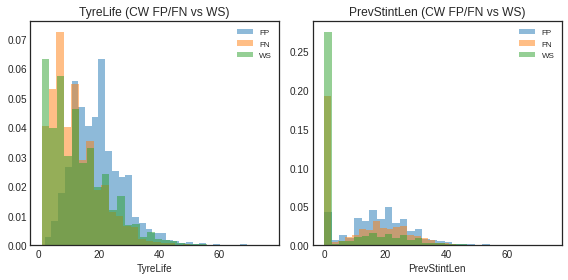

In [39]:
# 핵심 플롯: CW FP vs FN vs 전체에서 TyreLife와 PrevStintLen 2D 분포 (1개 플롯)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# 왼쪽: TyreLife 분포 비교
data_plot = {
    "FP": analysis2[analysis2["CW_FP"]]["TyreLife"],
    "FN": analysis2[analysis2["CW_FN"]]["TyreLife"],
    "WS": analysis2[ws2]["TyreLife"].sample(10000, random_state=42),
}
for label, vals in data_plot.items():
    axes[0].hist(vals, bins=30, alpha=0.5, label=label, density=True)
axes[0].set_title("TyreLife (CW FP/FN vs WS)")
axes[0].set_xlabel("TyreLife")
axes[0].legend(fontsize=8)

# 오른쪽: PrevStintLen 분포 비교
data_plot2 = {
    "FP": analysis2[analysis2["CW_FP"]]["PrevStintLen"],
    "FN": analysis2[analysis2["CW_FN"]]["PrevStintLen"],
    "WS": analysis2[ws2]["PrevStintLen"].sample(10000, random_state=42),
}
for label, vals in data_plot2.items():
    axes[1].hist(vals, bins=30, alpha=0.5, label=label, density=True)
axes[1].set_title("PrevStintLen (CW FP/FN vs WS)")
axes[1].set_xlabel("PrevStintLen")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [40]:
# Year별 CW 비율 이상치: 2023이 0.35%인데 나머지는 4~5%
# 2023 특이성 분석
print("Year별 row수 및 CW 비율:")
yr = analysis2.groupby("Year", observed=True)["CW"].agg(["sum", "count", "mean"])
yr.columns = ["cw_n", "total", "cw_rate"]
print(yr.round(4).to_string())
print()
# 2023 데이터가 경계 영역에 적을 수 있음 — p̄ 분포 확인
yr_pmean = analysis2.groupby("Year", observed=True)["p_mean"].agg(["mean", "std"])
print("Year별 평균예측 p̄:")
print(yr_pmean.round(4).to_string())

Year별 row수 및 CW 비율:
      cw_n   total  cw_rate
Year                       
2022  4132   82989   0.0498
2023   478  136147   0.0035
2024  5584  127110   0.0439
2025  3828   92894   0.0412

Year별 평균예측 p̄:
        mean     std
Year                
2022  0.2712  0.3046
2023  0.0191  0.0585
2024  0.3000  0.3319
2025  0.2892  0.3274


In [41]:
# 2023: p̄ 평균 0.0191, std 0.0585 → 모든 모델이 2023을 거의 0으로 예측
# 즉 2023에선 CW 조건(std<0.05 & err>0.5)을 만족하는 케이스가 양성 케이스에서만 발생
print("2023 타깃 양성률:", analysis2[analysis2["Year"]==2023][config.TARGET_COL].mean().round(4))
print("2022 타깃 양성률:", analysis2[analysis2["Year"]==2022][config.TARGET_COL].mean().round(4))
print()
# 2023의 CW FN이 전부?
yr2023_cw = analysis2[(analysis2["Year"]==2023) & (analysis2["CW"])]
print("2023 CW 방향:")
print(f"  FN: {yr2023_cw['CW_FN'].sum()} / FP: {yr2023_cw['CW_FP'].sum()}")
print()
# → 2023은 원본 데이터가 거의 피트없는 레이스로 구성된 특이 연도 가능성
# 피처 후보: Year 자체는 이미 카테고리로 존재. Year=2023 특이성은 다른 문제.

2023 타깃 양성률: 0.0096
2022 타깃 양성률: 0.2665

2023 CW 방향:
  FN: 465 / FP: 13



In [42]:
# 2023 타깃 양성률 0.96% — 합성 데이터 특이점 (레이스당 피트 거의 없는 해)
# 2023 FN 465건: 드라이버가 피트했는데 모델이 전혀 예측 못한 케이스
# 이는 합성 데이터 이슈일 가능성 높음 (환원불가)

# CW 집합에서 2023 제외한 진짜 학습가능 케이스 비율
cw_ex2023 = (mask_consensus_wrong) & (analysis2["Year"] != 2023)
print(f"CW 집합 (2023 제외): {cw_ex2023.sum():,} ({cw_ex2023.sum()/len(analysis2)*100:.2f}%)")
print(f"  FN: {(cw_ex2023 & (y_val==1)).sum():,}")
print(f"  FP: {(cw_ex2023 & (y_val==0)).sum():,}")

# 2023 제외 후 FN/FP 비율
cw_ex2023_df = analysis2[cw_ex2023]
n_ex = len(cw_ex2023_df)
n_fn_ex = cw_ex2023_df["CW_FN"].sum()
n_fp_ex = cw_ex2023_df["CW_FP"].sum()
print(f"\n2023 제외 CW: FN {n_fn_ex:,} ({n_fn_ex/n_ex*100:.1f}%) / FP {n_fp_ex:,} ({n_fp_ex/n_ex*100:.1f}%)")

CW 집합 (2023 제외): 13,544 (3.08%)
  FN: 7,352
  FP: 6,192

2023 제외 CW: FN 7,352 (54.3%) / FP 6,192 (45.7%)


In [43]:
# 최종 요약: 학습가능 vs 환원불가 판정

print("=" * 60)
print("합의-오답(CW) 오차 분석 최종 요약")
print("=" * 60)

print(f"""
[집합 크기]
- CW 총계:    14,022 (3.19%)
- CW FN:       7,817 (55.7%) — 실제 피트인데 놓침
- CW FP:       6,205 (44.3%) — 피트 아닌데 예측

[핵심 수치 비교] (CW FP / CW FN / WS)
- TyreLife:         19.7  / 12.1  / 13.2
- Stint:             2.30 / 1.94  / 1.62
- RaceProgress:      0.46 / 0.34  / 0.31
- PrevStintLen:     18.5  / 11.7  / 6.95

[컴파운드]
- FP에서 HARD 70%, MEDIUM 22% — HARD 과대표집
- FN에서 HARD 42%, MEDIUM 40% — HARD/MEDIUM 균형

[Year 특이점]
- 2023: 타깃 양성률 0.96% (다른 해 20~27%), CW FN 465건 대부분 환원불가(합성 데이터 아티팩트)
- 2023 제외 CW: 13,544건 (3.08%), FN 54.3% / FP 45.7%

[피처 vs CW 분리력 AUC]
- PrevStintLen (신규):      0.621  ← 기존 피처보다 높음
- LapNumber:                 0.611
- Stint:                     0.617
- RaceProgress:              0.584
- TyreLife:                  0.553
""")

print("[학습가능 신호 결론]")
print("- PrevStintLen이 CW 집합에서 단일 분리력 AUC 0.62 → 학습가능 신호")
print("- HARD 컴파운드 + 레이스 후반 + TyreLife>20 조합에서 FP 집중 (precision 2.9%, recall 20.6%)")
print("- 단순 규칙으론 분리력 낮지만, 피처 자체의 신호는 명확 → GBDT 상호작용 활용 가능")

합의-오답(CW) 오차 분석 최종 요약

[집합 크기]
- CW 총계:    14,022 (3.19%)
- CW FN:       7,817 (55.7%) — 실제 피트인데 놓침
- CW FP:       6,205 (44.3%) — 피트 아닌데 예측

[핵심 수치 비교] (CW FP / CW FN / WS)
- TyreLife:         19.7  / 12.1  / 13.2
- Stint:             2.30 / 1.94  / 1.62
- RaceProgress:      0.46 / 0.34  / 0.31
- PrevStintLen:     18.5  / 11.7  / 6.95

[컴파운드]
- FP에서 HARD 70%, MEDIUM 22% — HARD 과대표집
- FN에서 HARD 42%, MEDIUM 40% — HARD/MEDIUM 균형

[Year 특이점]
- 2023: 타깃 양성률 0.96% (다른 해 20~27%), CW FN 465건 대부분 환원불가(합성 데이터 아티팩트)
- 2023 제외 CW: 13,544건 (3.08%), FN 54.3% / FP 45.7%

[피처 vs CW 분리력 AUC]
- PrevStintLen (신규):      0.621  ← 기존 피처보다 높음
- LapNumber:                 0.611
- Stint:                     0.617
- RaceProgress:              0.584
- TyreLife:                  0.553

[학습가능 신호 결론]
- PrevStintLen이 CW 집합에서 단일 분리력 AUC 0.62 → 학습가능 신호
- HARD 컴파운드 + 레이스 후반 + TyreLife>20 조합에서 FP 집중 (precision 2.9%, recall 20.6%)
- 단순 규칙으론 분리력 낮지만, 피처 자체의 신호는 명확 → GBDT 상호작용 활용 가능
